In [1]:
import sqlite3

# Create an in-memory SQLite database
conn = sqlite3.connect('ads_data.db')

# Load your existing dataframe into a SQL table
df.to_sql('campaigns', conn, if_exists='replace', index=False)

print("Data loaded into SQL table successfully")

NameError: name 'df' is not defined

In [2]:
from google.colab import files
uploaded = files.upload()

Saving global_ads_performance_dataset.csv to global_ads_performance_dataset.csv


In [4]:
import sqlite3
import pandas as pd

# Assuming the CSV file is named 'global_ads_performance_dataset.csv'
# and is available in the current directory after upload.
df = pd.read_csv('global_ads_performance_dataset.csv')

# Create an in-memory SQLite database
conn = sqlite3.connect('ads_data.db')

# Load your existing dataframe into a SQL table
df.to_sql('campaigns', conn, if_exists='replace', index=False)

print("Data loaded into SQL table successfully")

Data loaded into SQL table successfully


In [5]:
query = """
SELECT
    platform,
    AVG(CTR) as avg_ctr,
    AVG(CPC) as avg_cpc,
    AVG(CPA) as avg_cpa,
    AVG(ROAS) as avg_roas,
    COUNT(*) as num_campaigns
FROM campaigns
GROUP BY platform
ORDER BY avg_roas DESC
"""

result = pd.read_sql_query(query, conn)
print(result)

     platform   avg_ctr   avg_cpc    avg_cpa  avg_roas  num_campaigns
0  TikTok Ads  0.054963  1.009978  29.196711  9.538600            450
1    Meta Ads  0.024983  1.316095  39.096921  6.915730            630
2  Google Ads  0.039856  2.149069  64.064653  4.113028            720


In [6]:
query2 = """
WITH platform_avg AS (
    SELECT
        platform,
        AVG(ROAS) as avg_roas,
        AVG(CPA) as avg_cpa
    FROM campaigns
    GROUP BY platform
)
SELECT
    platform,
    avg_roas,
    avg_cpa,
    RANK() OVER (ORDER BY avg_roas DESC) as roas_rank
FROM platform_avg
"""

result2 = pd.read_sql_query(query2, conn)
print(result2)

     platform  avg_roas    avg_cpa  roas_rank
0  TikTok Ads  9.538600  29.196711          1
1    Meta Ads  6.915730  39.096921          2
2  Google Ads  4.113028  64.064653          3


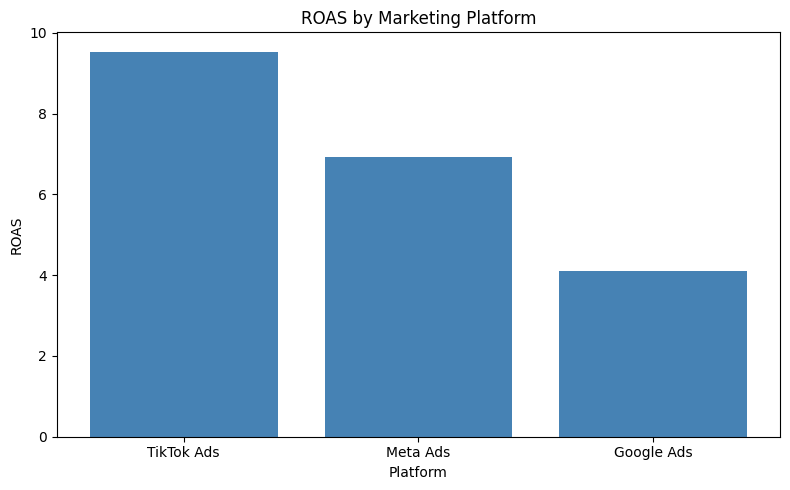

In [8]:
import matplotlib.pyplot as plt

# Create platform_summary_sorted from the 'result' DataFrame
# The 'result' DataFrame contains 'platform' and 'avg_roas'
platform_summary_sorted = result.set_index('platform').rename(columns={'avg_roas': 'ROAS'})

plt.figure(figsize=(8,5))
plt.bar(platform_summary_sorted.index, platform_summary_sorted['ROAS'], color='steelblue')
plt.title('ROAS by Marketing Platform')
plt.xlabel('Platform')
plt.ylabel('ROAS')
plt.tight_layout()
plt.savefig('roas_by_platform.png')
plt.show()